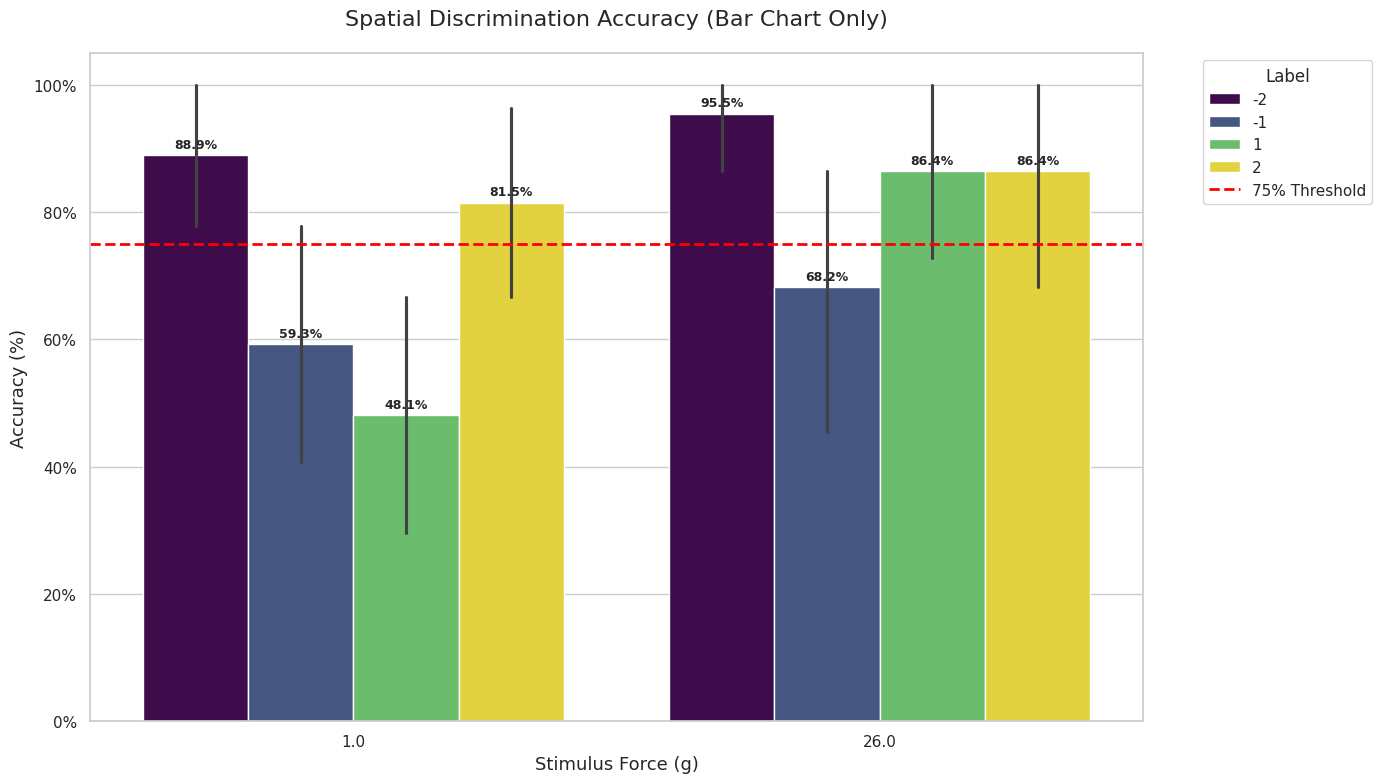


[Condition-specific Accuracy Summary]
Label              -2        -1         1         2
Force_Value                                        
1.0          0.888889  0.592593  0.481481  0.814815
26.0         0.954545  0.681818  0.863636  0.863636


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_SpatialDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    # 리스트 내포를 사용하여 데이터 통합
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 데이터 전처리
    # Force에서 숫자 추출
    if df_merged['Force'].dtype == 'object':
        df_merged['Force_Value'] = df_merged['Force'].str.replace('g', '').astype(float)
    else:
        df_merged['Force_Value'] = df_merged['Force']

    # Comparison_Target에서 Label 추출
    df_merged['Label'] = df_merged['Comparison_Target'].str.replace('g', '').astype(int)

    # -4, -3 값 제외
    df_filtered = df_merged[~df_merged['Label'].isin([-4, -3,4,3])].copy()

    # 데이터 정렬 (범례 순서를 위해)
    df_filtered = df_filtered.sort_values(by=['Label', 'Force_Value'])

    # 3. 시각화 설정
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 8))

    # [Only Bar Chart]
    # errorbar=None으로 위스커 제거, line plot은 아예 생략
    ax = sns.barplot(
        data=df_filtered,
        x='Force_Value',
        y='IsCorrect',
        hue='Label',
        palette='viridis' # 색상 테마 (선택 사항)
    )

    ax.axhline(0.75, color='red', linestyle ='--',linewidth = 2,label='75% Threshold' )

    for container in ax.containers:
        labels = [f'{val*100:.1f}%' for val in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight='bold')

    # 4. 그래프 디테일 설정
    plt.title('Spatial Discrimination Accuracy (Bar Chart Only)', fontsize=16, pad=20)
    plt.xlabel('Stimulus Force (g)', fontsize=13)
    plt.ylabel('Accuracy (%)', fontsize=13)
    plt.ylim(0, 1.05)

    # Y축 퍼센트 형식 표시
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # 범례 설정
    plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # 요약 데이터 출력
    print("\n[Condition-specific Accuracy Summary]")
    print(df_filtered.groupby(['Force_Value', 'Label'])['IsCorrect'].mean().unstack())

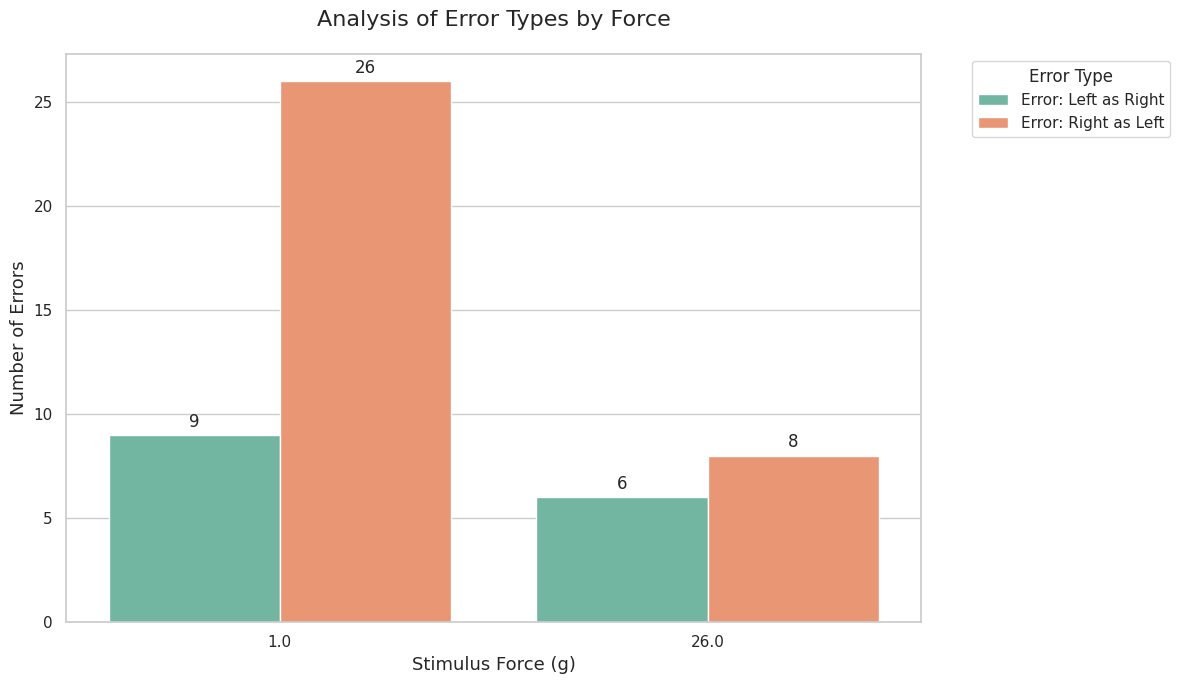


[오답 유형별 발생 횟수 요약]
Error_Type   Error: Left as Right  Error: Right as Left
Force_Value                                            
1.0                             9                    26
26.0                            6                     8


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_SpatialDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 데이터 전처리 및 오답 유형 정의
    # Force 숫자 추출
    if df_merged['Force'].dtype == 'object':
        df_merged['Force_Value'] = df_merged['Force'].str.replace('g', '').astype(float)
    else:
        df_merged['Force_Value'] = df_merged['Force']

    # Label 추출 및 -4, -3 제외
    df_merged['Label'] = df_merged['Comparison_Target'].str.replace('g', '').astype(int)
    df_filtered = df_merged[~df_merged['Label'].isin([-4, -3])].copy()

    # 오답 유형 분류 함수
    def classify_error(row):
        if row['IsCorrect'] == 1:
            return 'Correct'
        elif row['Target_Response'] == 'Left' and row['User_Response'] == 'Right':
            return 'Error: Left as Right'
        elif row['Target_Response'] == 'Right' and row['User_Response'] == 'Left':
            return 'Error: Right as Left'
        else:
            return 'Other Error'

    df_filtered['Error_Type'] = df_filtered.apply(classify_error, axis=1)

    # 3. 오답 발생 빈도 계산 (Error 케이스만 추출)
    error_only = df_filtered[df_filtered['Error_Type'].str.contains('Error')].copy()

    # Force별로 각 오답 유형이 몇 번 발생했는지 카운트
    error_counts = error_only.groupby(['Force_Value', 'Error_Type']).size().reset_index(name='Count')

    # 4. 시각화 (오답 유형 분석)
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    ax = sns.barplot(
        data=error_counts,
        x='Force_Value',
        y='Count',
        hue='Error_Type',
        palette='Set2'
    )

    # 막대 위에 숫자 표시
    for container in ax.containers:
        ax.bar_label(container, padding=3)

    # 그래프 디테일 설정
    plt.title('Analysis of Error Types by Force', fontsize=16, pad=20)
    plt.xlabel('Stimulus Force (g)', fontsize=13)
    plt.ylabel('Number of Errors', fontsize=13)
    plt.legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # 5. 요약 데이터 출력 (표 형태)
    print("\n[오답 유형별 발생 횟수 요약]")
    summary = error_counts.pivot(index='Force_Value', columns='Error_Type', values='Count').fillna(0)
    print(summary)

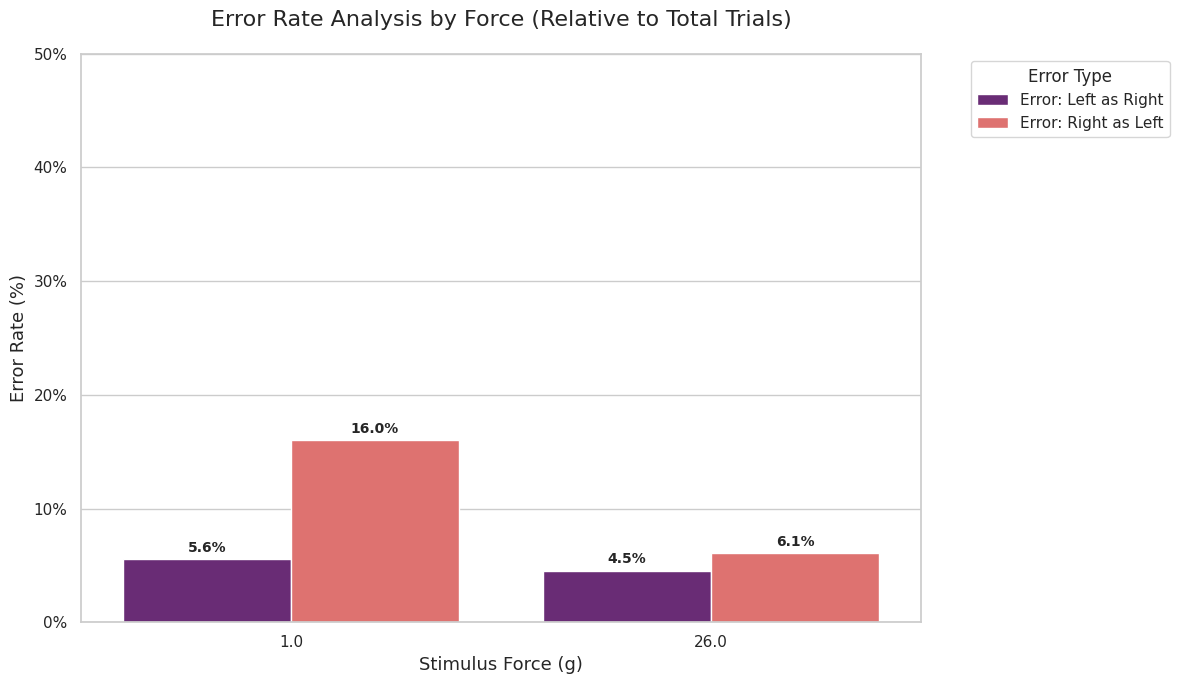


[Force별 오답 비율(%) 요약]
Error_Type   Error: Left as Right  Error: Right as Left
Force_Value                                            
1.0                      5.555556             16.049383
26.0                     4.545455              6.060606


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_SpatialDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 데이터 전처리
    df_merged['Force_Value'] = df_merged['Force'].str.replace('g', '').astype(float)
    df_merged['Label'] = df_merged['Comparison_Target'].str.replace('g', '').astype(int)
    df_filtered = df_merged[~df_merged['Label'].isin([-4, -3])].copy()

    # 오답 유형 분류
    def classify_error(row):
        if row['IsCorrect'] == 1:
            return 'Correct'
        elif row['Target_Response'] == 'Left' and row['User_Response'] == 'Right':
            return 'Error: Left as Right'
        elif row['Target_Response'] == 'Right' and row['User_Response'] == 'Left':
            return 'Error: Right as Left'
        else:
            return 'Other Error'

    df_filtered['Error_Type'] = df_filtered.apply(classify_error, axis=1)

    # 3. 오답 비율(Rate) 계산
    # Force별 전체 시행 횟수 계산
    total_counts = df_filtered.groupby('Force_Value').size().reset_index(name='Total_Trials')

    # Force별 오답 유형별 횟수 계산
    error_counts = df_filtered.groupby(['Force_Value', 'Error_Type']).size().reset_index(name='Count')

    # 데이터 병합 및 비율 계산
    error_analysis = pd.merge(error_counts, total_counts, on='Force_Value')
    error_analysis['Error_Rate'] = error_analysis['Count'] / error_analysis['Total_Trials']

    # 오답 유형만 추출 (Correct 제외)
    error_plot_df = error_analysis[error_analysis['Error_Type'].str.contains('Error')].copy()

    # 4. 시각화 (오답 비율 분석)
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    ax = sns.barplot(
        data=error_plot_df,
        x='Force_Value',
        y='Error_Rate',
        hue='Error_Type',
        palette='magma'
    )

    # 막대 위에 비율(%) 표시
    for container in ax.containers:
        labels = [f'{v*100:.1f}%' for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10, fontweight='bold')

    # 그래프 디테일 설정
    plt.title('Error Rate Analysis by Force (Relative to Total Trials)', fontsize=16, pad=20)
    plt.xlabel('Stimulus Force (g)', fontsize=13)
    plt.ylabel('Error Rate (%)', fontsize=13)
    plt.ylim(0, max(error_plot_df['Error_Rate'].max() * 1.2, 0.5)) # 여백 확보

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # 요약 데이터 출력
    print("\n[Force별 오답 비율(%) 요약]")
    summary = error_plot_df.pivot(index='Force_Value', columns='Error_Type', values='Error_Rate').fillna(0)
    print(summary * 100) # 퍼센트로 출력